In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Dataset/Housing.csv'
sample = pd.read_csv(file_path)
sample.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Checking Null values
sample.isnull().sum()*100/sample.shape[0]
# There are no NULL values in the dataset, hence it is clean.

,0
price,0.0
area,0.0
bedrooms,0.0
bathrooms,0.0
stories,0.0
mainroad,0.0
guestroom,0.0
basement,0.0
hotwaterheating,0.0
airconditioning,0.0


In [ ]:
X = sample[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y = sample["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X shape:", X.shape)
print("Y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
X_train.head()


X shape: (545, 5)
Y shape: (545,)
X_train shape: (436, 5)
X_test shape: (109, 5)
y_train shape: (436,)
y_test shape: (109,)


,area,bedrooms,bathrooms,stories,parking
46,6000,3,2,4,1
93,7200,3,2,1,3
335,3816,2,1,1,2
412,2610,3,1,2,0
471,3750,3,1,2,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

X_train_final = np.hstack((np.ones((X_train_scaled.shape[0], 1)),X_train_scaled))
X_test_final = np.hstack((np.ones((X_test_scaled.shape[0], 1)),X_test_scaled))

print (type(X_train_scaled))
print(X_train_scaled.shape)
print(X_train_final.shape)

X_train_scaled_df = pd.DataFrame( X_train_scaled, columns=X_train.columns)
X_train_scaled_df.head()

<class 'numpy.ndarray'>
(436, 5)
(436, 6)


,area,bedrooms,bathrooms,stories,parking
0,0.384168,0.055271,1.539173,2.587644,0.367957
1,0.929181,0.055271,1.539173,-0.912499,2.709987
2,-0.607755,-1.283514,-0.557950,-0.912499,1.538972
3,-1.155492,0.055271,-0.557950,0.254215,-0.803059
4,-0.637730,0.055271,-0.557950,0.254215,-0.803059


In [ ]:
# Cost Function
def cost_function (X, y, theta):
  m = len(y)
  predictions = X.dot(theta)
  errors = np.subtract(predictions, y)
  sqrErrors = np.square(errors)
  return 1/(2*m) * np.sum(sqrErrors)

# Gradient descent
def gradient_descent (X, y, theta, alpha, iterations):
  m=len(y)
  cost_history = np.zeros(iterations)

  for i in range(iterations):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sum_delta = (alpha / m) * X.transpose().dot(errors);
    theta = theta - sum_delta
    cost_history[i] = cost_function(X, y, theta)
  return theta, cost_history


a) Develop a gradient decent training and evaluation code, from scratch, that predicts housing price based on the following input variables:

area, bedrooms, bathrooms, stories, parking

Identify the best parameters for your linear regression model, based on the above input variables.

Plot the training and validation losses (in a single graph, but two different lines). For the learning rate, explore different values between 0.1 and 0.01 (your choice). Initialize your parameters (thetas to zero). For the training iteration, choose what you believe fits the best.

In [ ]:
theta = np.zeros(6)
print (theta)

initial_cost =cost_function(X_train_final, y_train_scaled, theta)

print("Initial cost:", initial_cost)

[0. 0. 0. 0. 0. 0.]
Initial cost: 0.5


Theta: [-2.27651740e-16  3.87129836e-01  6.48385574e-02  3.21759679e-01
  2.41378363e-01  1.64338973e-01]
Final Training Loss: 0.21891618306047642


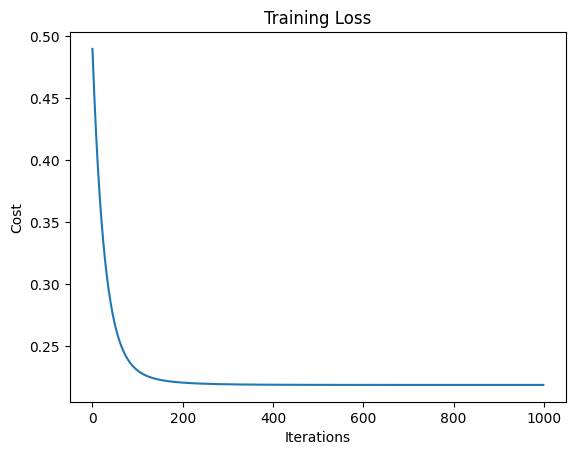

In [99]:
iterations = 1000
theta = np.zeros(6)
alpha = 0.01
theta, training_loss = gradient_descent(X_train_final, y_train_scaled, theta, alpha, iterations)

print("Theta:", theta)
print("Final Training Loss:", training_loss[-1])

plt.plot(training_loss)

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training Loss')

plt.show()

In [100]:
validation_loss = cost_function(X_test_final, y_test_scaled, theta)

print("Validation Loss:", validation_loss)

Validation Loss: 0.3717936082095219


In [95]:
def gradient_descent_validation(X, y, X_val, y_val, theta, alpha, iterations):

    m = len(y)

    training_loss = np.zeros(iterations)
    validation_loss = np.zeros(iterations)

    for i in range(iterations):

        predictions = X.dot(theta)

        errors = np.subtract(predictions, y)

        sum_delta = (alpha / m) * X.transpose().dot(errors)

        theta = theta - sum_delta

        training_loss[i] = cost_function(X, y, theta)

        validation_loss[i] = cost_function(X_val, y_val, theta)
    return theta, training_loss, validation_loss

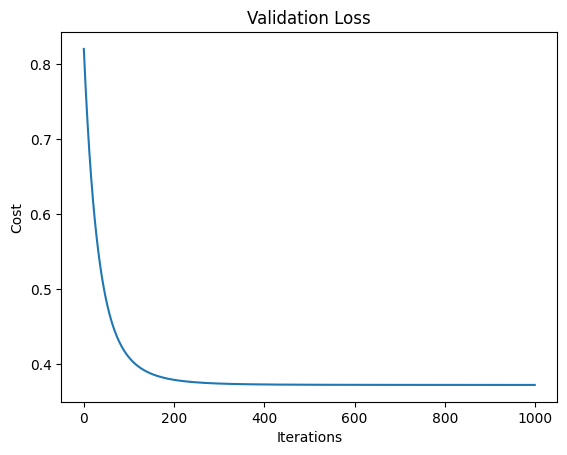

In [103]:
iterations = 1000
theta = np.zeros(6)
alpha = 0.01

theta, training_loss, validation_loss = gradient_descent_validation(X_train_final,y_train_scaled,X_test_final,y_test_scaled,theta,alpha,iterations)

plt.plot(validation_loss)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Validation Loss')
plt.show()

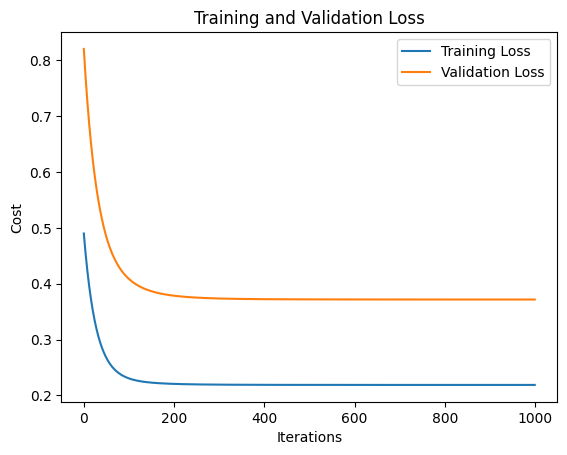

In [104]:
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [113]:
learning_rates = [0.1, 0.05, 0.025, 0.01]

training_losses = {}
validation_losses = {}

for alpha in learning_rates:

    theta = np.zeros(6)

    theta, training_loss, validation_loss = gradient_descent_validation(
        X_train_final,
        y_train_scaled,
        X_test_final,
        y_test_scaled,
        theta,
        alpha,
        iterations
    )

    training_losses[alpha] = training_loss
    validation_losses[alpha] = validation_loss

    print("Learning Rate:", alpha)
    print("Final Training Loss:", training_loss[-1])
    print("Final Validation Loss:", validation_loss[-1])
    print()

Learning Rate: 0.1
Final Training Loss: 0.21891605834628747
Final Validation Loss: 0.3717855635726848

Learning Rate: 0.05
Final Training Loss: 0.21891605834628747
Final Validation Loss: 0.3717855635726854

Learning Rate: 0.025
Final Training Loss: 0.2189160583462908
Final Validation Loss: 0.3717855648909972

Learning Rate: 0.01
Final Training Loss: 0.21891618306047642
Final Validation Loss: 0.3717936082095219



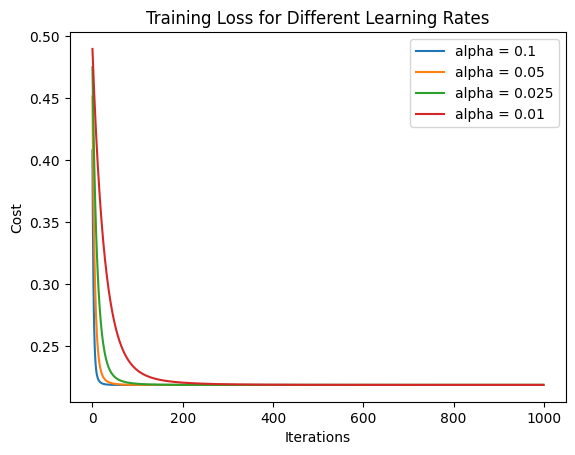

In [114]:
for alpha in learning_rates:
    plt.plot(training_losses[alpha], label=f'alpha = {alpha}')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training Loss for Different Learning Rates')
plt.legend()
plt.show()

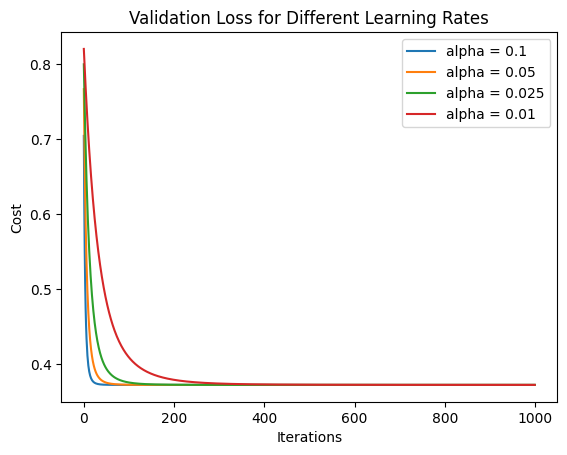

In [115]:
for alpha in learning_rates:
    plt.plot(validation_losses[alpha], label=f'alpha = {alpha}')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Validation Loss for Different Learning Rates')
plt.legend()
plt.show()

In [116]:
best_alpha = 0.1

best_theta = np.zeros(X_train_final.shape[1])

best_theta, best_training_loss, best_validation_loss = gradient_descent_validation(
    X_train_final,
    y_train_scaled,
    X_test_final,
    y_test_scaled,
    best_theta,
    best_alpha,
    iterations
)

In [117]:
print("Best Learning Rate:", best_alpha)
print("Best Theta:", best_theta)
print("Final Training Loss:", best_training_loss[-1])
print("Final Validation Loss:", best_validation_loss[-1])

Best Learning Rate: 0.1
Best Theta: [-2.21891822e-16  3.87286026e-01  6.43370255e-02  3.21994183e-01
  2.41665544e-01  1.64211554e-01]
Final Training Loss: 0.21891605834628747
Final Validation Loss: 0.3717855635726848


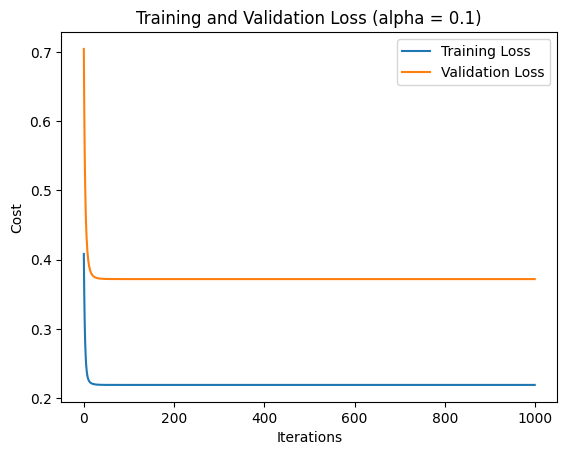

In [118]:
plt.plot(best_training_loss, label='Training Loss')
plt.plot(best_validation_loss, label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training and Validation Loss (alpha = 0.1)')
plt.legend()
plt.show()

 1.b) Develop a gradient decent training and evaluation code, from scratch, that predicts housing price based on the following input variables:

Area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea

Identify the best parameters for your linear regression model, based on the above input variables.

Plot the training and validation losses (in a single graph, but two different lines) over your training iteration. Compare your linear regression model against problem 1 a. For the learning rate, explore different values between 0.1 and 0.01 (your choice). Initialize your parameters (thetas to zero). For the training iteration, choose what you believe fits the best.

In [124]:
X_b = sample[["area","bedrooms", "bathrooms","stories","mainroad","guestroom","basement","hotwaterheating","airconditioning","parking","prefarea"]].copy()
y_b = sample["price"]
X_b.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,yes,no,no,no,yes,2,yes
1,8960,4,4,4,yes,no,no,no,yes,3,no
2,9960,3,2,2,yes,no,yes,no,no,2,yes
3,7500,4,2,2,yes,no,yes,no,yes,3,yes
4,7420,4,1,2,yes,yes,yes,no,yes,2,no


In [125]:
varlist = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

X_b[varlist] = X_b[varlist].apply(binary_map)
X_b.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,1,0,0,0,1,2,1
1,8960,4,4,4,1,0,0,0,1,3,0
2,9960,3,2,2,1,0,1,0,0,2,1
3,7500,4,2,2,1,0,1,0,1,3,1
4,7420,4,1,2,1,1,1,0,1,2,0


In [126]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    random_state=42
)
print(X_train_b.shape)
print(X_test_b.shape)

(436, 11)
(109, 11)


In [128]:
scaler_X_b = StandardScaler()

X_train_b_scaled = scaler_X_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_X_b.transform(X_test_b)

scaler_y_b = StandardScaler()

y_train_b_scaled = scaler_y_b.fit_transform(y_train_b.values.reshape(-1, 1)).flatten()

y_test_b_scaled = scaler_y_b.transform(y_test_b.values.reshape(-1, 1)).flatten()

X_train_b_final = np.c_[np.ones(X_train_b_scaled.shape[0]),X_train_b_scaled]
X_test_b_final = np.c_[np.ones(X_test_b_scaled.shape[0]),X_test_b_scaled]

print(X_train_b_final.shape)
print(X_test_b_final.shape)

(436, 12)
(109, 12)


In [129]:
theta = np.zeros(12)
iterations_b = 1000
alpha_b = 0.01

theta_b = np.zeros(X_train_b_final.shape[1])

theta_b, training_loss_b, validation_loss_b = gradient_descent_validation(X_train_b_final,y_train_b_scaled,X_test_b_final, y_test_b_scaled,theta_b,alpha_b,iterations_b
)

print("Theta:", theta_b)
print("Final Training Loss:", training_loss_b[-1])
print("Final Validation Loss:", validation_loss_b[-1])

Theta: [-2.08148992e-16  2.97323011e-01  3.45440306e-02  3.01197148e-01
  2.06941539e-01  8.26031683e-02  5.39440356e-02  1.17566489e-01
  8.89222932e-02  2.12917992e-01  1.20384037e-01  1.53519727e-01]
Final Training Loss: 0.16094108789510153
Final Validation Loss: 0.2919140759057991


In [130]:
learning_rates_b = [0.1, 0.05, 0.025, 0.01]

training_losses_b = {}
validation_losses_b = {}

for alpha in learning_rates_b:

    theta_b = np.zeros(X_train_b_final.shape[1])

    theta_b, training_loss_b, validation_loss_b = gradient_descent_validation(
        X_train_b_final,
        y_train_b_scaled,
        X_test_b_final,
        y_test_b_scaled,
        theta_b,
        alpha,
        iterations_b
    )

    training_losses_b[alpha] = training_loss_b
    validation_losses_b[alpha] = validation_loss_b

    print("Learning Rate:", alpha)
    print("Final Training Loss:", training_loss_b[-1])
    print("Final Validation Loss:", validation_loss_b[-1])
    print()

Learning Rate: 0.1
Final Training Loss: 0.16093978294563435
Final Validation Loss: 0.2920150112481503

Learning Rate: 0.05
Final Training Loss: 0.16093978294563435
Final Validation Loss: 0.2920150112412086

Learning Rate: 0.025
Final Training Loss: 0.16093978295424413
Final Validation Loss: 0.292014857434646

Learning Rate: 0.01
Final Training Loss: 0.16094108789510153
Final Validation Loss: 0.2919140759057991



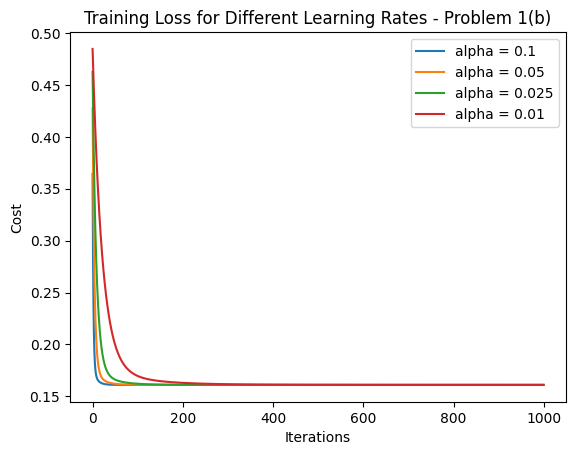

In [131]:
for alpha in learning_rates_b:
    plt.plot(training_losses_b[alpha], label=f'alpha = {alpha}')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training Loss for Different Learning Rates - Problem 1(b)')
plt.legend()
plt.show()

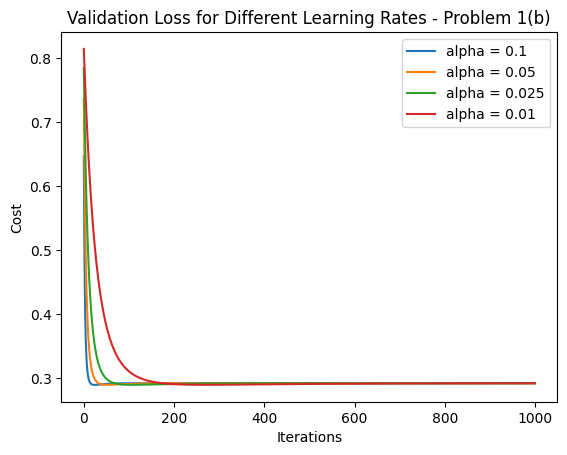

In [132]:
for alpha in learning_rates_b:
    plt.plot(validation_losses_b[alpha], label=f'alpha = {alpha}')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Validation Loss for Different Learning Rates - Problem 1(b)')
plt.legend()
plt.show()

In [133]:
best_alpha_b = 0.1

best_theta_b = np.zeros(X_train_b_final.shape[1])

best_theta_b, best_training_loss_b, best_validation_loss_b = gradient_descent_validation(
    X_train_b_final,
    y_train_b_scaled,
    X_test_b_final,
    y_test_b_scaled,
    best_theta_b,
    best_alpha_b,
    iterations_b
)

print("Best Learning Rate:", best_alpha_b)
print("Best Theta:", best_theta_b)
print("Final Training Loss:", best_training_loss_b[-1])
print("Final Validation Loss:", best_validation_loss_b[-1])

Best Learning Rate: 0.1
Best Theta: [-1.87133693e-16  2.98063477e-01  3.33852093e-02  3.01245687e-01
  2.08380468e-01  8.20808454e-02  5.31712296e-02  1.18750425e-01
  8.87875386e-02  2.12417150e-01  1.20336794e-01  1.53520754e-01]
Final Training Loss: 0.16093978294563435
Final Validation Loss: 0.2920150112481503


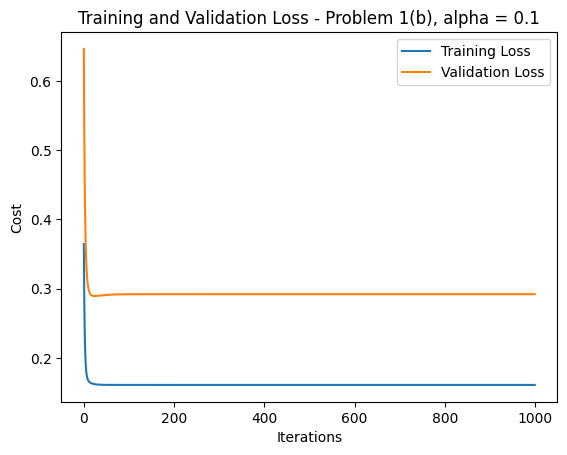

In [134]:
plt.plot(best_training_loss_b, label='Training Loss')
plt.plot(best_validation_loss_b, label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training and Validation Loss - Problem 1(b), alpha = 0.1')
plt.legend()
plt.show()

In [135]:
training_improvement = best_training_loss[-1] - best_training_loss_b[-1]
validation_improvement = best_validation_loss[-1] - best_validation_loss_b[-1]

print("Training Loss Improvement:", training_improvement)
print("Validation Loss Improvement:", validation_improvement)

Training Loss Improvement: 0.057976275400653116
Validation Loss Improvement: 0.07977055232453445


2.a) Repeat problem 1 a, this time with input normalization and input standardization as part of your pre-processing logic. You need to perform two separate trainings for standardization and normalization. In both cases, you do not need to normalize the output!

Plot the training and validation losses for both training and validation set based on input standardization and input normalization. Compare your training accuracy between both scaling approaches as well as the baseline training in problem 1 a. Which input scaling achieves the best training? Explain your results.



In [138]:
scaler_X_2a_std = StandardScaler()

X_train_2a_std = scaler_X_2a_std.fit_transform(X_train)
X_test_2a_std = scaler_X_2a_std.transform(X_test)
X_train_2a_std_final = np.c_[
    np.ones(X_train_2a_std.shape[0]),
    X_train_2a_std
]

X_test_2a_std_final = np.c_[
    np.ones(X_test_2a_std.shape[0]),
    X_test_2a_std
]

print(X_train_2a_std_final.shape)
print(X_test_2a_std_final.shape)

(436, 6)
(109, 6)


In [141]:
theta_2a= np.zeros(6)
iterations_2a = 1000
alpha_2a = 0.01

theta_2a, training_loss_2a_std, validation_loss_2a_std = gradient_descent_validation(
    X_train_2a_std_final,
    y_train,
    X_test_2a_std_final,
    y_test,
    theta_2a,
    alpha_2a,
    iterations_2a
)

print("Theta:", theta_2a)
print("Final Training Loss:", training_loss_2a_std[-1])
print("Final Validation Loss:", validation_loss_2a_std[-1])

Theta: [4706324.19866291  679784.16108007  113853.85524508  564996.83769347
  423850.53400102  288572.51539751]
Final Training Loss: 675004510848.4789
Final Validation Loss: 1146408168889.5422


In [146]:
scaler_X_2a_norm = MinMaxScaler()

X_train_2a_norm = scaler_X_2a_norm.fit_transform(X_train)
X_test_2a_norm = scaler_X_2a_norm.transform(X_test)

X_train_2a_norm_final = np.c_[
    np.ones(X_train_2a_norm.shape[0]),
    X_train_2a_norm
]

X_test_2a_norm_final = np.c_[
    np.ones(X_test_2a_norm.shape[0]),
    X_test_2a_norm
]

print(X_train_2a_norm_final.shape)
print(X_test_2a_norm_final.shape)

(436, 6)
(109, 6)


In [149]:
theta_2a_norm = np.zeros(6)

print(theta_2a_norm)

alpha_2a_norm = 0.01

theta_2a_norm, training_loss_2a_norm, validation_loss_2a_norm = gradient_descent_validation(
    X_train_2a_norm_final,
    y_train,
    X_test_2a_norm_final,
    y_test,
    theta_2a_norm,
    alpha_2a_norm,
    iterations_2a
)

print("Theta:", theta_2a_norm)
print("Final Training Loss:", training_loss_2a_norm[-1])
print("Final Validation Loss:", validation_loss_2a_norm[-1])

[0. 0. 0. 0. 0. 0.]
Theta: [3003436.32770682 1594381.78836447 1471384.436388   1121038.15840209
 1433551.94486797 1336236.55962768]
Final Training Loss: 849748793747.9463
Final Validation Loss: 1458033578362.7144


In [150]:
learning_rates_2a = [0.1, 0.05, 0.025, 0.01]

training_losses_2a_std = {}
validation_losses_2a_std = {}

for alpha in learning_rates_2a:

    theta = np.zeros(X_train_2a_std_final.shape[1])

    theta, train_loss, val_loss = gradient_descent_validation(
        X_train_2a_std_final,
        y_train,
        X_test_2a_std_final,
        y_test,
        theta,
        alpha,
        iterations_2a
    )

    training_losses_2a_std[alpha] = train_loss
    validation_losses_2a_std[alpha] = val_loss

    print("Learning Rate:", alpha)
    print("Final Training Loss:", train_loss[-1])
    print("Final Validation Loss:", val_loss[-1])
    print()

Learning Rate: 0.1
Final Training Loss: 675004105663.2902
Final Validation Loss: 1146360772862.6836

Learning Rate: 0.05
Final Training Loss: 675004105663.29
Final Validation Loss: 1146360772862.6858

Learning Rate: 0.025
Final Training Loss: 675004105663.3005
Final Validation Loss: 1146360776932.8364

Learning Rate: 0.01
Final Training Loss: 675004510848.4789
Final Validation Loss: 1146408168889.5422



In [151]:
training_losses_2a_norm = {}
validation_losses_2a_norm = {}

for alpha in learning_rates_2a:

    theta = np.zeros(X_train_2a_norm_final.shape[1])

    theta, train_loss, val_loss = gradient_descent_validation(
        X_train_2a_norm_final,
        y_train,
        X_test_2a_norm_final,
        y_test,
        theta,
        alpha,
        iterations_2a
    )

    training_losses_2a_norm[alpha] = train_loss
    validation_losses_2a_norm[alpha] = val_loss

    print("Learning Rate:", alpha)
    print("Final Training Loss:", train_loss[-1])
    print("Final Validation Loss:", val_loss[-1])
    print()

Learning Rate: 0.1
Final Training Loss: 679326731187.338
Final Validation Loss: 1156827430615.0107

Learning Rate: 0.05
Final Training Loss: 704035112745.0892
Final Validation Loss: 1196908120183.3801

Learning Rate: 0.025
Final Training Loss: 756881074479.962
Final Validation Loss: 1286272444485.2034

Learning Rate: 0.01
Final Training Loss: 849748793747.9463
Final Validation Loss: 1458033578362.7144



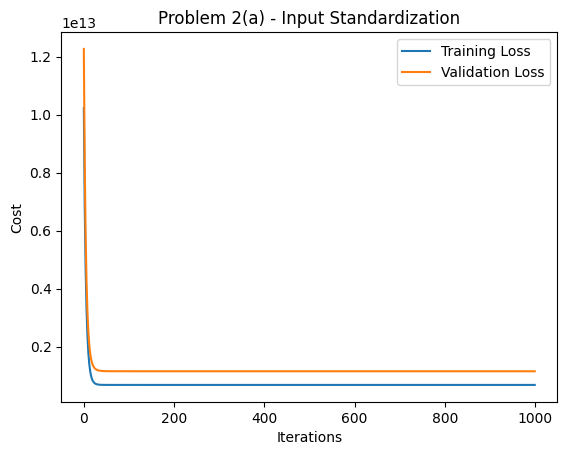

In [152]:
plt.plot(training_losses_2a_std[0.1], label='Training Loss')
plt.plot(validation_losses_2a_std[0.1], label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 2(a) - Input Standardization')
plt.legend()
plt.show()

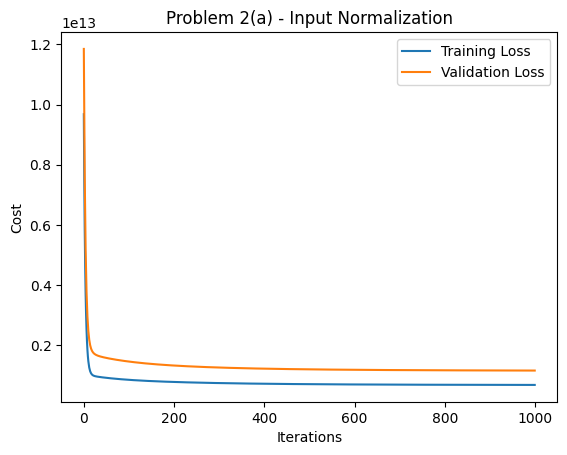

In [153]:
plt.plot(training_losses_2a_norm[0.1], label='Training Loss')
plt.plot(validation_losses_2a_norm[0.1], label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 2(a) - Input Normalization')
plt.legend()
plt.show()

In [154]:
y_train_pred_1a_scaled = X_train_final.dot(best_theta)
y_test_pred_1a_scaled = X_test_final.dot(best_theta)

y_train_pred_1a = scaler_y.inverse_transform(
    y_train_pred_1a_scaled.reshape(-1, 1)
).flatten()

y_test_pred_1a = scaler_y.inverse_transform(
    y_test_pred_1a_scaled.reshape(-1, 1)
).flatten()

baseline_train_loss_1a = (1 / (2 * len(y_train))) * np.sum(
    (y_train_pred_1a - y_train.values) ** 2
)

baseline_val_loss_1a = (1 / (2 * len(y_test))) * np.sum(
    (y_test_pred_1a - y_test.values) ** 2
)

print("Problem 1(a) Baseline Training Loss:", baseline_train_loss_1a)
print("Problem 1(a) Baseline Validation Loss:", baseline_val_loss_1a)

Problem 1(a) Baseline Training Loss: 675004105663.2902
Problem 1(a) Baseline Validation Loss: 1146360772862.6829


2.b) Repeat problem 1 b, this time with input normalization and input standardization as part of your pre-processing logic. You need to perform two separate trainings for standardization and normalization. In both cases, you do not need to normalize the output!

Plot the training and validation losses for both training and validation sets based on input standardization and input normalization. Compare your training accuracy between both scaling approaches and the baseline training in problem 1 b. Which input scaling achieves the best training? Explain your results.

In [155]:
scaler_X_2b_std = StandardScaler()

X_train_2b_std = scaler_X_2b_std.fit_transform(X_train_b)
X_test_2b_std = scaler_X_2b_std.transform(X_test_b)
X_train_2b_std_final = np.c_[
    np.ones(X_train_2b_std.shape[0]),
    X_train_2b_std
]

X_test_2b_std_final = np.c_[
    np.ones(X_test_2b_std.shape[0]),
    X_test_2b_std
]

print(X_train_2b_std_final.shape)
print(X_test_2b_std_final.shape)

(436, 12)
(109, 12)


In [157]:
theta_2b_std = np.zeros(12)

print(theta_2b_std)

alpha_2b_std = 0.01
iterations_2b = 1000

theta_2b_std, training_loss_2b_std, validation_loss_2b_std = gradient_descent_validation(
    X_train_2b_std_final,
    y_train_b,
    X_test_2b_std_final,
    y_test_b,
    theta_2b_std,
    alpha_2b_std,
    iterations_2b
)
print("Theta:", theta_2b_std)
print("Final Training Loss:", training_loss_2b_std[-1])
print("Final Validation Loss:", validation_loss_2b_std[-1])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Theta: [4706324.19866291  522087.04752932   60657.90506096  528889.87497578
  363380.87926714  145047.7854994    94723.52054041  206441.94710708
  156143.91037252  373875.28580191  211389.44518885  269574.36203818]
Final Training Loss: 496244544318.54193
Final Validation Loss: 900111363844.0188


In [158]:
learning_rates_2b = [0.1, 0.05, 0.025, 0.01]

training_losses_2b_std = {}
validation_losses_2b_std = {}

for alpha in learning_rates_2b:

    theta = np.zeros(X_train_2b_std_final.shape[1])

    theta, train_loss, val_loss = gradient_descent_validation(
        X_train_2b_std_final,
        y_train_b,
        X_test_2b_std_final,
        y_test_b,
        theta,
        alpha,
        iterations_2b
    )

    training_losses_2b_std[alpha] = train_loss
    validation_losses_2b_std[alpha] = val_loss

    print("Learning Rate:", alpha)
    print("Final Training Loss:", train_loss[-1])
    print("Final Validation Loss:", val_loss[-1])
    print()

Learning Rate: 0.1
Final Training Loss: 496240500004.89264
Final Validation Loss: 900396859859.4867

Learning Rate: 0.05
Final Training Loss: 496240500004.89264
Final Validation Loss: 900396859838.0833

Learning Rate: 0.025
Final Training Loss: 496240500031.44006
Final Validation Loss: 900396385598.1146

Learning Rate: 0.01
Final Training Loss: 496244544318.54193
Final Validation Loss: 900111363844.0188



In [159]:
best_alpha_2b_std = 0.1

scaler_X_2b_norm = MinMaxScaler()

X_train_2b_norm = scaler_X_2b_norm.fit_transform(X_train_b)
X_test_2b_norm = scaler_X_2b_norm.transform(X_test_b)

X_train_2b_norm_final = np.c_[
    np.ones(X_train_2b_norm.shape[0]),
    X_train_2b_norm
]

X_test_2b_norm_final = np.c_[
    np.ones(X_test_2b_norm.shape[0]),
    X_test_2b_norm
]

print(X_train_2b_norm_final.shape)
print(X_test_2b_norm_final.shape)

(436, 12)
(109, 12)


In [160]:
theta_2b_norm = np.zeros(12)

training_losses_2b_norm = {}
validation_losses_2b_norm = {}

for alpha in learning_rates_2b:

    theta = np.zeros(X_train_2b_norm_final.shape[1])

    theta, train_loss, val_loss = gradient_descent_validation(
        X_train_2b_norm_final,
        y_train_b,
        X_test_2b_norm_final,
        y_test_b,
        theta,
        alpha,
        iterations_2b
    )

    training_losses_2b_norm[alpha] = train_loss
    validation_losses_2b_norm[alpha] = val_loss

    print("Learning Rate:", alpha)
    print("Final Training Loss:", train_loss[-1])
    print("Final Validation Loss:", val_loss[-1])
    print()


Learning Rate: 0.1
Final Training Loss: 500403900500.5454
Final Validation Loss: 891968202704.1312

Learning Rate: 0.05
Final Training Loss: 519822018821.4629
Final Validation Loss: 900914192484.2476

Learning Rate: 0.025
Final Training Loss: 560083195300.4042
Final Validation Loss: 947263417922.8794

Learning Rate: 0.01
Final Training Loss: 640942055907.615
Final Validation Loss: 1077541865435.6566



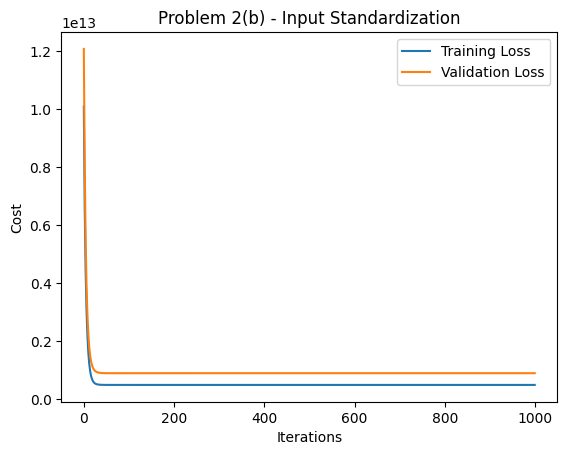

In [161]:
plt.plot(training_losses_2b_std[0.1], label='Training Loss')
plt.plot(validation_losses_2b_std[0.1], label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 2(b) - Input Standardization')
plt.legend()
plt.show()

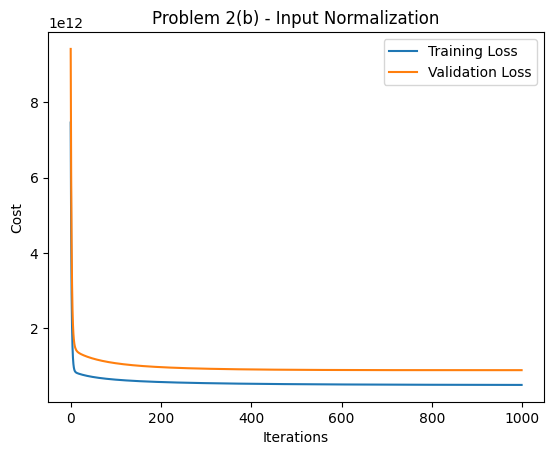

In [162]:
plt.plot(training_losses_2b_norm[0.1], label='Training Loss')
plt.plot(validation_losses_2b_norm[0.1], label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 2(b) - Input Normalization')
plt.legend()
plt.show()

In [164]:
y_train_pred_1b_scaled = X_train_b_final.dot(best_theta_b)
y_test_pred_1b_scaled = X_test_b_final.dot(best_theta_b)

y_train_pred_1b = scaler_y_b.inverse_transform(
    y_train_pred_1b_scaled.reshape(-1, 1)
).flatten()

y_test_pred_1b = scaler_y_b.inverse_transform(
    y_test_pred_1b_scaled.reshape(-1, 1)
).flatten()

baseline_train_loss_1b = (1 / (2 * len(y_train_b))) * np.sum(
    (y_train_pred_1b - y_train_b.values) ** 2
)

baseline_val_loss_1b = (1 / (2 * len(y_test_b))) * np.sum(
    (y_test_pred_1b - y_test_b.values) ** 2
)

print("Problem 1(b) Baseline Training Loss:", baseline_train_loss_1b)
print("Problem 1(b) Baseline Validation Loss:", baseline_val_loss_1b)

Problem 1(b) Baseline Training Loss: 496240500004.89264
Problem 1(b) Baseline Validation Loss: 900396859859.4862


3.a) Repeat problem 2 a, this time by adding a parameters penalty to your loss function. Note that in this case, you need to modify the gradient descent logic for your training set, but you don’t need to change your loss for the evaluation set.  

Plot your results (both training and evaluation losses) for the best input scaling approach (standardization or normalization). Explain your results and compare them against problem 2 a.


In [165]:
def gradient_descent_regularized(X, y, X_val, y_val, theta, alpha, iterations, lambda_):

    m = len(y)

    training_loss = np.zeros(iterations)
    validation_loss = np.zeros(iterations)

    for i in range(iterations):

        predictions = X.dot(theta)

        errors = np.subtract(predictions, y)

        gradient = (1 / m) * X.transpose().dot(errors)

        # Add L2 penalty, but do not penalize theta[0]
        penalty = (lambda_ / m) * theta
        penalty[0] = 0

        theta = theta - alpha * (gradient + penalty)

        training_loss[i] = cost_function(X, y, theta) + \
            (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)

        validation_loss[i] = cost_function(X_val, y_val, theta)

    return theta, training_loss, validation_loss

In [172]:
lambda_values = [0, 0.01, 0.1, 1, 10]

training_losses_3a = {}
validation_losses_3a = {}

for lambda_ in lambda_values:

    theta = np.zeros(6)

    theta, train_loss, val_loss = gradient_descent_regularized(
        X_train_2a_std_final,
        y_train,
        X_test_2a_std_final,
        y_test,
        theta,
        0.1,
        1000,
        lambda_
    )

    training_losses_3a[lambda_] = train_loss
    validation_losses_3a[lambda_] = val_loss

    print("Lambda:", lambda_)
    print("Final Training Loss:", train_loss[-1])
    print("Final Validation Loss:", val_loss[-1])
    print()

Lambda: 0
Final Training Loss: 675004105663.2902
Final Validation Loss: 1146360772862.6836

Lambda: 0.01
Final Training Loss: 675016240218.5042
Final Validation Loss: 1146366485461.9111

Lambda: 0.1
Final Training Loss: 675125432525.6849
Final Validation Loss: 1146417913664.2349

Lambda: 1
Final Training Loss: 676215509548.8853
Final Validation Loss: 1146933652803.8274

Lambda: 10
Final Training Loss: 686935784807.2144
Final Validation Loss: 1152228178686.857



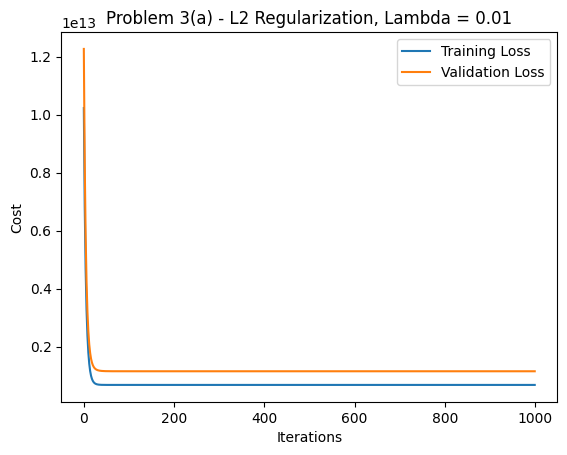

In [175]:
best_lambda_3a = 0.01

theta_3a = np.zeros(6)

theta_3a, training_loss_3a, validation_loss_3a = gradient_descent_regularized(
    X_train_2a_std_final,
    y_train,
    X_test_2a_std_final,
    y_test,
    theta_3a,
    0.1,
    1000,
    best_lambda_3a
)

plt.plot(training_loss_3a, label='Training Loss')
plt.plot(validation_loss_3a, label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 3(a) - L2 Regularization, Lambda = 0.01')
plt.legend()
plt.show()


b) Repeat problem 2 b, this time by adding a parameters penalty to your loss function. Note that in this case, you need to modify the gradient descent logic for your training set, but you don’t need to change your loss for the evaluation set.  
Plot your results (both training and evaluation losses) for the best input scaling approach (standardization or normalization). Explain your results and compare them against problem 2 b.

In [171]:
lambda_values_3b = [0, 0.01, 0.1, 1, 10]

training_losses_3b = {}
validation_losses_3b = {}

for lambda_ in lambda_values_3b:

    theta = np.zeros(12)

    theta, train_loss, val_loss = gradient_descent_regularized(
        X_train_2b_std_final,
        y_train_b,
        X_test_2b_std_final,
        y_test_b,
        theta,
        0.1,
        1000,
        lambda_
    )

    training_losses_3b[lambda_] = train_loss
    validation_losses_3b[lambda_] = val_loss

    print("Lambda:", lambda_)
    print("Final Training Loss:", train_loss[-1])
    print("Final Validation Loss:", val_loss[-1])
    print()

Lambda: 0
Final Training Loss: 496240500004.89264
Final Validation Loss: 900396859859.4867

Lambda: 0.01
Final Training Loss: 496252481467.9479
Final Validation Loss: 900399772828.1556

Lambda: 0.1
Final Training Loss: 496360297139.20337
Final Validation Loss: 900426018836.9554

Lambda: 1
Final Training Loss: 497436726500.53503
Final Validation Loss: 900691360801.0679

Lambda: 10
Final Training Loss: 508032873018.6545
Final Validation Loss: 903616055731.5443



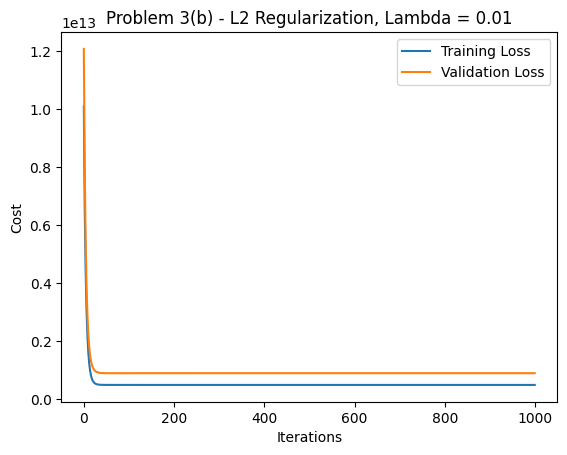

In [174]:
best_lambda_3b = 0.01

theta_3b = np.zeros(12)

theta_3b, training_loss_3b, validation_loss_3b = gradient_descent_regularized(
    X_train_2b_std_final,
    y_train_b,
    X_test_2b_std_final,
    y_test_b,
    theta_3b,
    0.1,
    1000,
    best_lambda_3b
)

plt.plot(training_loss_3b, label='Training Loss')
plt.plot(validation_loss_3b, label='Validation Loss')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 3(b) - L2 Regularization, Lambda = 0.01')
plt.legend()
plt.show()